"""Disclaimer: I am a Biochemistry Scholar. Not a math or computer science scholar.
This code is based on the fact that. 
for any odd prime p and q they will give either 1 or 3 mod 4.
for example p = 47 q =61. p = 3 mod 4 and q = 1 mod 4. 
if the semiprime is made up of factors which are odd.
then N should be either 1 mod 4 or 3 mod 4.
so if the N is 3 mod 4 then the factor sum p+q should be divided by 4.
if the N is 1 mod 4 then the factor sum p+q should be divided by 2.

but here we extended to other composite and primorial moduli.
"""

In [ ]:
"""
        any q 
    m  |  q mod m  |  q mod m
    ---------------------------
any  p |(p*q)mod m | (p*q)mod m
p    p |(p*q)mod m | (p*q)mod m

for the N (mod m) cant expect any value,  (p*q)mod m = N mod m  value is defined based on 
factors p mod m and q mod m.    

so is the p+q mod m. it is also restricted to a handful of values only.

for example when it is an odd semiprime so the factors should also be odd.
their sum (p+q) should be always even. 
we cant expect an odd factor sum. which  is just saying the factor sum is 
restricted to 0 mod 2.

we can extend to this any chosen and all moduli under N.

lets say an odd semiprime. N =r (mod 210). the r can never be a even number or a multiple of 5.
if (mod m)N = r is an even number or 5 then the N should be a multiple of 2 or 5.
so the we only have about  less than 105 residues for r when  N = r mod 210. 

so is the factor sum p+q values.  but they are restricted to even further down.


"""

In [ ]:
"""
Let me explain the method using a trivial and well understood case.
The possibilities of odd semiprime N mod 4 is either 1 or 4.

modular multiplication table for moduli 4
this table gives us all the possible combinations of p and q and r = N mod 4 space.
           any q
       4 | 1 | 3
     -----------
any    1 | 1 | 3  -  if N (mod 4) = 3 then the factor sum should be 0.
p      3 | 1 | 1      -
                         -
                            -
modular addition table for    -
the moduli 4 in the factor    -
sum space.                   -  
                            - 
the factor sums           -
       4 | 1 |  3        -
      -----------       - 
       1 | 2 |  0 <---   
       3 | 0 |  2
       
so if the N mod 4 is 1 then the factor sum is either 0 mod 4 or 2 mod 4. 
But if the N mod 4 is 3 then the factor sum is strictly restricted to just 0 mod 4.
and we also have one more information about the factors. one factor 1 mod 4 and another 3 mod 4.
But when the moduli become large so are the combinations and
 this combinatorial information is not so useful in the factoring process.

searching for through primes is hard because we dont know which is prime
and which is not. but searching for a composite (p+q) is much easy as we 
know most of the things about it from the modular arithmetic.

But we can use the factor sum information,so we dont to check other numbers 
while searching in the (2*(sqrt(N)) to N) space for 
the factor sum when using the x^2 - bx +N =0 equation to find factors.

"""


In [ ]:
""" 
The key fact we can use any moduli to reduce the search space.
But the problem is when the moduli is a prime like 7,13,1009. 
on average they give about (m+1)/2 residues. and we can combine multiple 
the residues of different moduli using CRT as they are coprime all the 
residue combinations are allowed for the factor sum. But the reduced search space
vs the CRT combination explosion will nullify the effective factoring process.

But when we combine a highly composite moduli like a primorial with a small 
prime moduli, we will get a bigger M_eff and in most cases some of the residus 
cancel out in the CRT process due to no possible number which can satisfy 
both constraints and the allowed factor sum residues will be a tiny fraction
of the combined modulus. Thus reducing the search space and time.
This is the heart of the semiprime modular restriction conjecture. 

The previous investigations on this matter may brushed this off because of the 
fact that we cant combine more and more moduli to get a bigger modulus to 
reduce the search space because as we add more moduli the residue possibilites
get out of hand quickly. also the reason previous investigations may have abandoned it 
because it cant compete with the heuristic algorithms interms of actual run time.
and also they may tried only prime moduli for reducing the search space which i also
did in my previous implementations. 

The key lies on the composites and primorials which in combinations can quickly
lead to the exact factor sum and dont exponentially blow up the combinations as 
some residues which are always incompatible during the CRT process. 

"""



In [ ]:
import pandas as pd
import numpy as np
import json

"""
##############################################################################
5 is omitted because you know why!
But running this for other moduli please remove the if value%5 !=0
otherwise the signatures wont be meaningful and you know why!
##############################################################################
"""
mods = 30030

# Generate odd numbers from 1 to mods
odd_numbers = np.arange(1, mods, 2)

# Remove multiples of 5 from the odd numbers
odd_numbers = odd_numbers[odd_numbers % 5 != 0]

# Create the DataFrame with the product of row and column indices, modulo mods
df = pd.DataFrame(np.outer(odd_numbers, odd_numbers) % mods, index=odd_numbers, columns=odd_numbers)

# Step 1: Create the dictionary for all values, including 0
result_dict = {value: set() for value in odd_numbers if value%5 !=0}  # All odd numbers except multiples of 5
result_dict[0] = set() # Include key 0 please dont remove it serves an important function

# Step 2: Loop through the DataFrame to find all occurrences of each value
for row_index, row in df.iterrows():  # row_index is the row header
    for col_index, value in row.items():  # col_index is the column header
        if value in result_dict:
            # Add the (row_index + col_index) % 30030 to the dictionary for this value
            result_dict[value].add((row_index + col_index) % mods)

# Convert the sets to sorted lists for unique and ordered results
for key in result_dict:
    result_dict[key] = sorted(result_dict[key])

# Convert dictionary keys to standard `int` (or `str`) to make them serializable
result_dict = {int(key): value for key, value in result_dict.items()}

# Step 3: Print a small sample of the result_dict to verify
for key, value in list(result_dict.items())[:5]:  # First 5 items
    print(f"{key}: {value}")

# Step 4: Save the result as a Python-friendly JSON file
with open(f'/content/signature_{mods}.json', 'w') as json_file:
    json.dump(result_dict, json_file, indent=4)

# Step 5: Save the result as a plain text file
with open(f'/content/signature_{mods}.txt', 'w') as txt_file:
    txt_file.write(str(result_dict))

print("Files saved successfully!")

KeyboardInterrupt: 

# Basic descrptive stats of the allowed residues for the selected moduli
for example if  N mod(30030) == 1. then we will have 1008 allowed residues. so we only have to check those 1008 residues out of 30030 while finding the factor sum. 
there are only 1008 * total_numbers in the search space/30030 numbers are there to check in the search space. 

In [ ]:
# Get the first and last key-value pairs
first_key, first_value = next(iter(result_dict.items()))  # Get the first key-value pair
last_key, last_value = list(result_dict.items())[-2]  # Get the last key-value pair the 0 is there for preventing some errors.

# Get the length of the first and last value (which are lists)
first_length = len(first_value)
last_length = len(last_value)

# Print the lengths
print(f"Length of the first item (key {first_key}): {first_length}")
print(f"Length of the last item (key {last_key}): {last_length}")


Length of the first item (key 1): 1008
Length of the last item (key 0): 0


In [ ]:
print(first_key, first_value)

1 [2, 40, 92, 118, 128, 152, 212, 260, 272, 310, 338, 442, 470, 482, 520, 548, 568, 652, 680, 730, 740, 778, 818, 832, 860, 862, 898, 922, 932, 950, 988, 992, 1010, 1042, 1052, 1070, 1118, 1142, 1168, 1192, 1252, 1262, 1300, 1322, 1328, 1378, 1478, 1510, 1520, 1532, 1538, 1588, 1598, 1702, 1720, 1730, 1742, 1780, 1790, 1808, 1822, 1850, 1868, 1910, 1912, 1972, 2000, 2032, 2042, 2050, 2092, 2108, 2120, 2158, 2182, 2248, 2290, 2302, 2312, 2318, 2368, 2378, 2500, 2522, 2560, 2570, 2578, 2588, 2638, 2648, 2680, 2708, 2732, 2752, 2770, 2780, 2812, 2830, 2858, 2890, 2900, 2962, 2990, 3040, 3082, 3142, 3148, 3170, 3172, 3298, 3302, 3340, 3352, 3358, 3368, 3380, 3418, 3428, 3512, 3550, 3562, 3590, 3610, 3628, 3638, 3670, 3688, 3722, 3758, 3782, 3820, 3848, 3898, 3940, 4030, 4052, 4132, 4138, 4160, 4198, 4250, 4292, 4342, 4370, 4408, 4418, 4468, 4502, 4528, 4552, 4562, 4580, 4600, 4628, 4640, 4678, 4682, 4772, 4810, 4822, 4832, 4838, 4888, 4892, 4990, 5018, 5020, 5042, 5108, 5122, 5150, 5188, 5

# for the selected moduli 30030, for some N mod(30030) we can have as much as 9008 residues. 
any odd semiprime should leave one of the 12013 residues.

In [ ]:
# 1. Find the key with the maximum length of the value (list)
max_key = None
max_value_len = 0
for key, value in result_dict.items():
    if len(value) > max_value_len:
        max_value_len = len(value)
        max_key = key

# 2. Print the max length key and value
print(f"Max length key: {max_key}")
print(f"Max length value: {max_value_len}")

# 3. Count the number of keys in the dictionary
total_keys = len(result_dict)

# 4. Print the number of keys in the dictionary
print(f"Total number of keys in the dictionary: {total_keys}")


Max length key: 9009
Max length value: 9009
Total number of keys in the dictionary: 12013


# Another example
if N (mod 30030) = 17. then we only have to check 210 residues out of the 30030 possible residues.
if N (mod 30030) = 3. then we have to check 756 residues out of the 30030 possible residues.

In [ ]:
# Iterate through the first 10 items of the dictionary
for key, value in list(result_dict.items())[:10]:
    print(f"Length of the list for key {key}: {len(value)}")

Length of the list for key 1: 1008
Length of the list for key 3: 756
Length of the list for key 7: 840
Length of the list for key 9: 1512
Length of the list for key 11: 792
Length of the list for key 13: 780
Length of the list for key 17: 210
Length of the list for key 19: 540
Length of the list for key 21: 1890
Length of the list for key 23: 336


# For the analysis of the distribution of the allowed residues for all N = r mod(30030).

In [ ]:
# Define the file path to save the key and length data
output_file_path = '/content/30030key_lengths.txt'

# Open the file in write mode
with open(output_file_path, 'w') as f:
    # Iterate through the dictionary
    for key, value in result_dict.items():
        # Write the key and the length of its value to the file, separated by a colon
        f.write(f"{key}: {len(value)}\n")

print(f"Key and length data saved to {output_file_path}")

Key and length data saved to /content/30030key_lengths.txt


Minimum length of lists: 0
Maximum length of lists: 9009
Average length of lists: 839.93
Median length of lists: 672.0


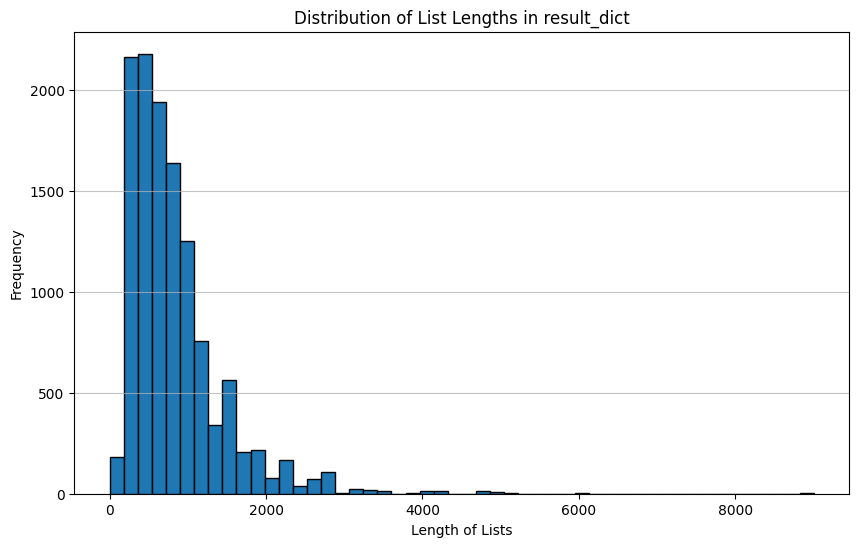

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the lengths of all lists in the dictionary
list_lengths = [len(value) for value in result_dict.values()]

# Calculate key statistics
min_length = np.min(list_lengths)
max_length = np.max(list_lengths)
average_length = np.mean(list_lengths)
median_length = np.median(list_lengths)

print(f"Minimum length of lists: {min_length}")
print(f"Maximum length of lists: {max_length}")
print(f"Average length of lists: {average_length:.2f}")
print(f"Median length of lists: {median_length}")

# Plot the distribution of list lengths
plt.figure(figsize=(10, 6))
plt.hist(list_lengths, bins=50, edgecolor='black')
plt.title('Distribution of List Lengths in result_dict')
plt.xlabel('Length of Lists')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:

range_size = 100

# Find the maximum length to determine the upper bound for ranges
max_length = max(list_lengths)

# Create a dictionary to store the counts for each range
range_counts = {}

# Iterate through the list lengths and count occurrences in each range
for length in list_lengths:
    # Determine the lower bound of the range
    lower_bound = (length // range_size) * range_size
    # Define the range as a tuple (lower_bound, upper_bound)
    current_range = (lower_bound, lower_bound + range_size)

    # Increment the count for the corresponding range
    if current_range in range_counts:
        range_counts[current_range] += 1
    else:
        range_counts[current_range] = 1

# Sort the ranges for cleaner output
sorted_ranges = sorted(range_counts.keys())

# Define the output file path
output_file_path = '/content/range_counts.txt'

# Open the file in write mode
with open(output_file_path, 'w') as f:
    # Write the counts for each range to the file
    for current_range in sorted_ranges:
        lower, upper = current_range
        # Adjust the upper bound for the last range to include the max_length
        if upper > max_length and lower <= max_length:
            upper = max_length
            f.write(f"Length {lower}-{upper}: {range_counts[current_range]} values\n")
        elif upper <= max_length:
            f.write(f"Length {lower}-{upper}: {range_counts[current_range]} values\n")

print(f"Range counts saved to {output_file_path}")

Range counts saved to /content/range_counts.txt


# for the primorial 2310. i did some analysis on the distribution of allowed residues for every r in N = r(mod 30030). 
but changed the file names somehow. Please first create the dictionary using 2310 in the first cell and run the below cells.

In [ ]:
import ast

# Define the file path
file_path = '/content/2310 signature.txt'

# Open and read the content of the file
with open(file_path, 'r') as f:
    file_content = f.read()

# Safely convert the string representation to a dictionary
loaded_dict = ast.literal_eval(file_content)

# Verify the type and a small sample of the loaded dictionary
print(type(loaded_dict))
for key, value in list(loaded_dict.items())[:5]:
    print(f"{key}: {value}")

<class 'dict'>
1: [2, 8, 20, 40, 58, 62, 68, 92, 118, 128, 152, 190, 202, 212, 218, 250, 260, 268, 272, 278, 310, 328, 338, 370, 398, 400, 422, 442, 460, 470, 482, 488, 502, 520, 530, 548, 568, 580, 590, 608, 652, 680, 712, 722, 730, 740, 772, 778, 790, 800, 818, 832, 838, 860, 862, 898, 922, 932, 950, 982, 988, 992, 1010, 1030, 1042, 1048, 1052, 1058, 1070, 1108, 1118, 1142, 1168, 1192, 1202, 1240, 1252, 1258, 1262, 1268, 1280, 1300, 1318, 1322, 1328, 1360, 1378, 1388, 1412, 1448, 1450, 1472, 1478, 1492, 1510, 1520, 1532, 1538, 1570, 1580, 1588, 1598, 1630, 1658, 1702, 1720, 1730, 1742, 1762, 1780, 1790, 1808, 1822, 1828, 1840, 1850, 1868, 1888, 1910, 1912, 1940, 1972, 1982, 2000, 2032, 2038, 2042, 2050, 2060, 2092, 2098, 2108, 2120, 2158, 2182, 2192, 2218, 2242, 2248, 2252, 2270, 2290, 2302, 2308]
3: [4, 24, 46, 56, 84, 136, 144, 164, 186, 196, 224, 266, 276, 284, 304, 326, 354, 364, 406, 416, 444, 466, 486, 494, 504, 546, 574, 584, 606, 626, 634, 686, 714, 724, 746, 766, 774, 794, 8

We can see that  if N = 1 mod(2310) we have 144 allowed residues for the factor sum. and so on.

In [ ]:
# Create a list called list_lengths by iterating through the loaded_dict and getting the length of each value
list_lengths = [len(value) for value in loaded_dict.values()]

# Verify the first few elements and the length of the list_lengths list
print("First 10 elements of list_lengths:", list_lengths[:10])
print("Length of list_lengths:", len(list_lengths))

First 10 elements of list_lengths: [144, 108, 140, 216, 132, 60, 30, 90, 315, 48]
Length of list_lengths: 924


we can anywhere from 30 to 683 allowed residues when using 2310. but it is completely defined and we can calculate the amount of allowed residues even when we dont have the dictionary and code by using a simple excel file or by hand if the moduli is small.

Heuristically or on average we get about 120 allowed residues for any residue N = r mod(2310). 
Which means when we use 2310 as a modular filter we only have to check 120/2310 residues in the search space. 


In [ ]:
# Calculate key statistics
min_length = np.min(list_lengths)
max_length = np.max(list_lengths)
average_length = np.mean(list_lengths)
median_length = np.median(list_lengths)

# Print key statistics
print(f"Minimum length of lists: {min_length}")
print(f"Maximum length of lists: {max_length}")
print(f"Average length of lists: {average_length:.2f}")
print(f"Median length of lists: {median_length}")

Minimum length of lists: 30
Maximum length of lists: 693
Average length of lists: 120.00
Median length of lists: 105.0


In [ ]:
# Define the range size
range_size = 30

# Find the maximum length to determine the upper bound for ranges
max_length = max(list_lengths)

# Create a dictionary to store the counts for each range
range_counts = {}

# Iterate through the list lengths and count occurrences in each range
for length in list_lengths:
    # Determine the lower bound of the range
    lower_bound = (length // range_size) * range_size
    # Define the range as a tuple (lower_bound, upper_bound)
    current_range = (lower_bound, lower_bound + range_size)

    # Increment the count for the corresponding range
    if current_range in range_counts:
        range_counts[current_range] += 1
    else:
        range_counts[current_range] = 1

# Sort the ranges for cleaner output
sorted_ranges = sorted(range_counts.keys())

# Define the output file path
output_file_path = '/content/range_counts_2310.txt'

# Open the file in write mode
with open(output_file_path, 'w') as f:
    # Write the counts for each range to the file
    for current_range in sorted_ranges:
        lower, upper = current_range
        # Adjust the upper bound for the last range to include the max_length
        if upper > max_length and lower <= max_length:
             # Check if the lower bound is within the max_length range
            if lower <= max_length:
                upper = max_length
                f.write(f"Length {lower}-{upper}: {range_counts[current_range]} values\n")
            else:
                 # Handle cases where the range starts beyond the max_length (shouldn't happen with integer division but as a safeguard)
                pass
        elif upper <= max_length:
            f.write(f"Length {lower}-{upper}: {range_counts[current_range]} values\n")


print(f"Range counts saved to {output_file_path}")

Range counts saved to /content/range_counts_2310.txt


In [ ]:
# Print key statistics (already calculated in a previous step)
print(f"Minimum length of lists: {min_length}")
print(f"Maximum length of lists: {max_length}")
print(f"Average length of lists: {average_length:.2f}")
print(f"Median length of lists: {median_length}")

# Define the file path for range counts
range_counts_file_path = '/content/range_counts_2310.txt'

# Read and print the content of the range counts file
print(f"\nDistribution of list lengths in ranges (from {range_counts_file_path}):")
try:
    with open(range_counts_file_path, 'r') as f:
        print(f.read())
except FileNotFoundError:
    print(f"Error: The file {range_counts_file_path} was not found.")


Minimum length of lists: 30
Maximum length of lists: 693
Average length of lists: 120.00
Median length of lists: 105.0

Distribution of list lengths in ranges (from /content/range_counts_2310.txt):
Length 30-60: 180 values
Length 60-90: 182 values
Length 90-120: 166 values
Length 120-150: 182 values
Length 150-180: 48 values
Length 180-210: 42 values
Length 210-240: 52 values
Length 240-270: 32 values
Length 270-300: 6 values
Length 300-330: 12 values
Length 360-390: 10 values
Length 390-420: 6 values
Length 450-480: 4 values
Length 690-693: 2 values



# for the distribution analysis of 30030. the file size become huge and mylaptop could not handle it.

In [ ]:
import json

# Function to save dictionary in parts based on key ranges
def save_in_ranges(result_dict):
    # Part 1: Keys from 1 to 9999 (odd numbers)
    part_1_dict = {key: value for key, value in result_dict.items() if 1 <= key <= 9999 and key % 2 != 0}

    # Part 2: Keys from 10001 to 19999 (odd numbers)
    part_2_dict = {key: value for key, value in result_dict.items() if 10001 <= key <= 19999 and key % 2 != 0}

    # Part 3: Keys from 20001 to 30029 (odd numbers)
    part_3_dict = {key: value for key, value in result_dict.items() if 20001 <= key <= 30029 and key % 2 != 0}

    # Save the parts to separate files
    with open('/content/30030_mod_signature_part_1.txt', 'w') as txt_file:
        txt_file.write(str(part_1_dict))
    print("Part 1 saved: 1 to 9999")

    with open('/content/30030_mod_signature_part_2.txt', 'w') as txt_file:
        txt_file.write(str(part_2_dict))
    print("Part 2 saved: 10001 to 19999")

    with open('/content/30030_mod_signature_part_3.txt', 'w') as txt_file:
        txt_file.write(str(part_3_dict))
    print("Part 3 saved: 20001 to 30029")

# Example usage with your result_dict (replace with your actual dictionary)
save_in_ranges(result_dict)
